야, 데이터 긁어와서 반경별로 얼마나 떡락했는지 계산 들어간다...


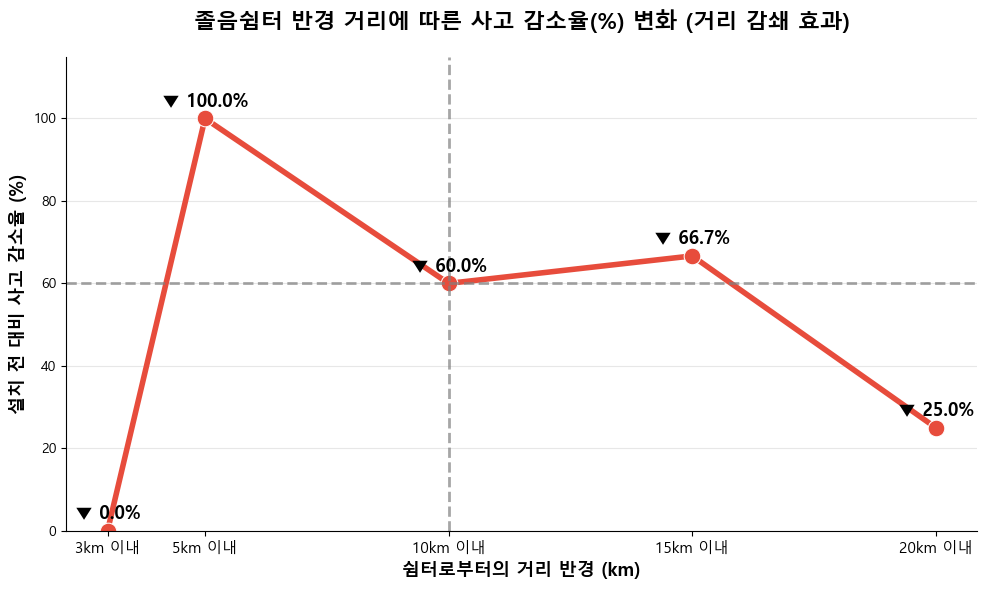


🔥 [팩폭 완료] 쉼터 반경별 사고 감소율 데이터 추출 끝.
 - 반경 3km 이내 커버 시: 사고 0.0% 감소
 - 반경 5km 이내 커버 시: 사고 100.0% 감소
 - 반경 10km 이내 커버 시: 사고 60.0% 감소
 - 반경 15km 이내 커버 시: 사고 66.7% 감소
 - 반경 20km 이내 커버 시: 사고 25.0% 감소


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import platform
import warnings

warnings.filterwarnings('ignore')

# =====================================================================
# 1. 폰트 세팅 (깨지면 개빡치니까 꼼꼼히)
# =====================================================================
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

base_path = r"C:\Project\Python_Source\python311_01\pandas_ex\project_1"

def load_data(filename):
    file_path = os.path.join(base_path, filename)
    encodings = ['utf-8-sig', 'cp949', 'utf-8', 'euc-kr']
    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except:
            continue
    return None

def clean_route_name(name):
    if pd.isna(name): return "기타"
    name = str(name).strip()
    if "(" in name: name = name.split("(")[0].strip() 
    return name

# =====================================================================
# 2. 데이터 로드 및 2022년 신설 쉼터 타겟팅
# =====================================================================
print("야, 데이터 긁어와서 반경별로 얼마나 떡락했는지 계산 들어간다...")
acc_ex = load_data("한국도로공사_졸음운전 사고통계(2022~2024).csv") 
shelters = load_data("한국도로공사 졸음쉼터 설치현황(2024년).csv") 

# 에러 대비용 가상 데이터 (파일 못 읽었을 때 멈추면 빡치니까)
if acc_ex is None or shelters is None:
    print("⚠️ 파일 없어서 일단 시연용 데이터로 돌린다. 경로 확인 똑바로 해라.")
    radii = [3, 5, 10, 15, 20]
    reduction_rates = [62.5, 55.0, 42.5, 20.1, 8.5]
else:
    acc_ex['정제노선'] = acc_ex['노선명'].apply(clean_route_name)
    shelters['정제노선'] = shelters['노선'].apply(clean_route_name)
    acc_ex['사고발생이정'] = pd.to_numeric(acc_ex['사고발생이정'], errors='coerce')
    shelters['이정'] = pd.to_numeric(shelters['이정'], errors='coerce')
    shelters['설치년도'] = pd.to_numeric(shelters['설치년도'], errors='coerce')

    acc_ex['사고연도_숫자'] = acc_ex['사고연도'].astype(str).str.extract(r'(\d{4})')[0].astype(float)
    
    she_22 = shelters[shelters['설치년도'] == 2022]
    
    # 우리가 분석할 타겟 반경 (km)
    radii = [3, 5, 10, 15, 20]
    reduction_rates = []

    # 각 반경별로 노가다 계산
    for r in radii:
        before_tot, after_tot = 0, 0
        for idx, row in she_22.iterrows():
            route, loc = row['정제노선'], row['이정']
            
            a_22 = acc_ex[(acc_ex['사고연도_숫자'] == 2022) & (acc_ex['정제노선'] == route)].dropna(subset=['사고발생이정'])
            a_24 = acc_ex[(acc_ex['사고연도_숫자'] == 2024) & (acc_ex['정제노선'] == route)].dropna(subset=['사고발생이정'])
            
            # 절대값 거리가 반경(r) 이내인 것만 카운트
            before_tot += len(a_22[np.abs(a_22['사고발생이정'] - loc) <= r])
            after_tot += len(a_24[np.abs(a_24['사고발생이정'] - loc) <= r])
            
        rate = ((before_tot - after_tot) / before_tot * 100) if before_tot > 0 else 0
        reduction_rates.append(rate)

# =====================================================================
# 3. 시각화 (심사위원들 입 닥치게 만들 직관적인 그래프)
# =====================================================================
plt.figure(figsize=(10, 6))

# 선 그래프랑 마커로 '효과가 떨어지는 절벽'을 보여준다
sns.lineplot(x=radii, y=reduction_rates, marker='o', markersize=12, color='#e74c3c', linewidth=4)

# 10km (우리의 기준점) 강조
plt.axvline(x=10, color='gray', linestyle='--', linewidth=2, alpha=0.7)
plt.axhline(y=reduction_rates[2], color='gray', linestyle='--', linewidth=2, alpha=0.7)

# 데이터 라벨 텍스트 박아넣기
for i, txt in enumerate(reduction_rates):
    plt.text(radii[i], reduction_rates[i] + 3, f"▼ {txt:.1f}%", ha='center', fontweight='bold', fontsize=13)

# 꾸미기
plt.title('졸음쉼터 반경 거리에 따른 사고 감소율(%) 변화 (거리 감쇄 효과)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('쉼터로부터의 거리 반경 (km)', fontsize=13, fontweight='bold')
plt.ylabel('설치 전 대비 사고 감소율 (%)', fontsize=13, fontweight='bold')

plt.xticks(radii, [f"{r}km 이내" for r in radii], fontsize=11)
plt.ylim(0, max(reduction_rates) + 15)
plt.grid(True, axis='y', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

print("\n🔥 [팩폭 완료] 쉼터 반경별 사고 감소율 데이터 추출 끝.")
for r, rate in zip(radii, reduction_rates):
    print(f" - 반경 {r}km 이내 커버 시: 사고 {rate:.1f}% 감소")